# Spatio-temporal prediction — Simulated data

Demonstration notebook for the simulated experiment from:
> Amato et al. (2020) *A Novel Framework for Spatio-Temporal Prediction of Environmental Data Using Deep Learning*, Scientific Reports.

All core logic lives in `stdl`. This notebook loads a pre-trained model (or trains one) and visualises the results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from stdl.config import ExperimentConfig
from stdl.data import load_data
from stdl.decomposition import svd_decompose
from stdl.evaluate import control_stats, spatial_mae, temporal_mae
from stdl.model import build_model
from stdl.train import train

## 1. Load config and data

In [2]:
cfg = ExperimentConfig.from_yaml(Path("../configs/simulated.yaml"))
bundle = load_data(cfg.data)
print(f"Train: {bundle.X_train.shape}, Val: {bundle.X_val.shape}, Test: {bundle.X_test.shape}")
print(f"Timesteps: {bundle.y_train.shape[1]}")

Train: (2000, 2), Val: (1000, 2), Test: (1000, 2)
Timesteps: 1008


## 2. SVD decomposition (EOF analysis)

The training field is decomposed into temporal basis functions $V$ and spatial coefficients $U$. The scree plot shows cumulative explained variance.

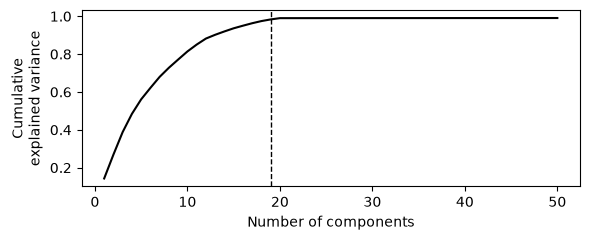

In [3]:
import tensorflow as tf

svd = svd_decompose(bundle.y_svd, cfg.model.n_eofs)

# Full SVD for scree plot (recompute without truncation)
Z = tf.cast(bundle.y_svd, tf.float32)
nS = tf.constant(Z.shape[0], dtype=tf.float32)
time_mean = tf.reduce_mean(Z, axis=0)
Ztilde = (Z - time_mean) / tf.sqrt(nS - 1)
s_full, _, _ = tf.linalg.svd(Ztilde)

cum_var = np.cumsum(np.array(s_full) ** 2) / np.sum(np.array(s_full) ** 2)

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.plot(np.arange(1, 51), cum_var[:50], c="black")
ax.axvline(cfg.model.n_eofs, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("Cumulative\nexplained variance")
ax.set_xlabel("Number of components")
plt.tight_layout()
plt.show()

## 3. Inspect EOF components

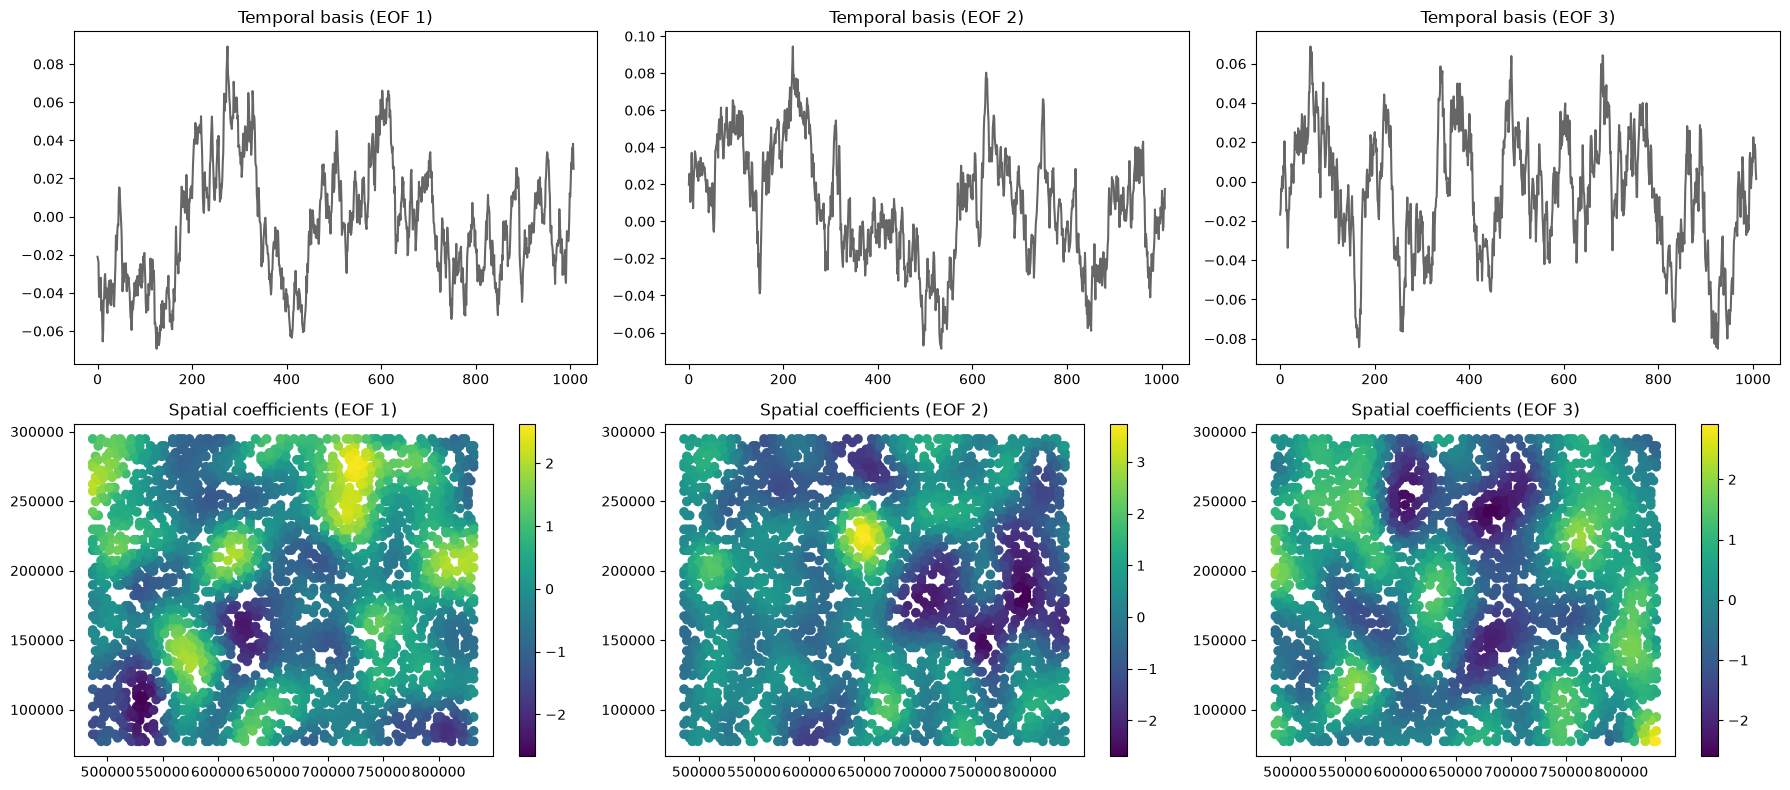

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for k in range(3):
    axes[0, k].plot(np.array(svd.v[:, k]), color="black", alpha=0.6)
    axes[0, k].set_title(f"Temporal basis (EOF {k+1})")

    sc = axes[1, k].scatter(
        bundle.raw_coords_train[:, 0],
        bundle.raw_coords_train[:, 1],
        c=np.array(svd.u[:, k]),
    )
    plt.colorbar(sc, ax=axes[1, k])
    axes[1, k].set_title(f"Spatial coefficients (EOF {k+1})")

plt.tight_layout()
plt.show()

## 4. Build and train model

In [5]:
model = build_model(cfg.model, svd)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ coords (InputLayer)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 300)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 300)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_out (BatchNormalization)     │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_coefficients (Dense)    │ (None, 19)             │         1,919 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ field (RecomposeLayer)          │ (None, 1008)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,027 (257.92 KB)

 Trainable params: 64,623 (252.43 KB)

 Non-trainable params: 1,404 (5.48 KB)

In [6]:
history = train(model, bundle, svd, cfg.train)

Epoch 1/2000
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - field_loss: 11.6016 - loss: 11.6005 - spatial_coefficients_loss: 0.8110 - val_field_loss: 13.3973 - val_loss: 13.4031 - val_spatial_coefficients_loss: 0.9090
Epoch 2/2000
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - field_loss: 10.2956 - loss: 10.2889 - spatial_coefficients_loss: 0.7132 - val_field_loss: 11.0336 - val_loss: 11.0557 - val_spatial_coefficients_loss: 0.7712
Epoch 3/2000
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - field_loss: 10.0234 - loss: 10.0175 - spatial_coefficients_loss: 0.6953 - val_field_loss: 9.9128 - val_loss: 9.9330 - val_spatial_coefficients_loss: 0.6997
Epoch 4/2000
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - field_loss: 9.8570 - loss: 9.8524 - spatial_coefficients_loss: 0.6846 - val_field_loss: 9.2962 - val_loss: 9.3109 - val_spatial_coefficients_loss: 0.6593
Epoch 5/2000
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - field_loss: 9.7315 - loss: 9.7277 - spatial_coefficients_loss: 0.6765 - val_field_loss: 8.8987 - val_los

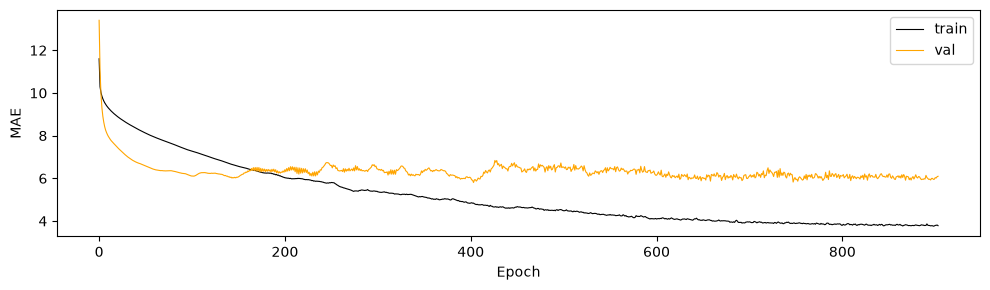

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history.history["loss"], label="train", color="black", linewidth=0.8)
ax.plot(history.history["val_loss"], label="val", color="orange", linewidth=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Predictions and evaluation

In [8]:
y_hat_test, _ = model.predict(bundle.X_test, verbose=0)
y_hat_mesh, _ = model.predict(bundle.X_mesh, verbose=0)

mae_t = temporal_mae(bundle.y_test, y_hat_test)
mae_s = spatial_mae(bundle.y_test, y_hat_test)
print(f"Mean temporal MAE : {mae_t.mean():.4f}")
print(f"Mean spatial MAE  : {mae_s.mean():.4f}")

Mean temporal MAE : 5.8745
Mean spatial MAE  : 5.8745


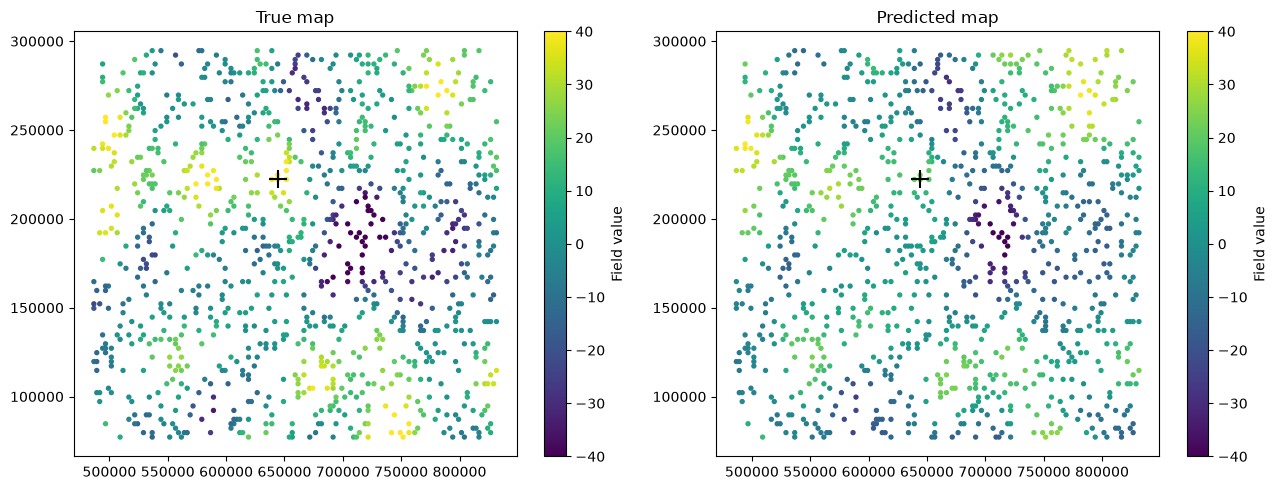

In [9]:
# Pick a random test location and timestep
rng = np.random.default_rng(12345)
loc = rng.integers(0, bundle.X_test.shape[0])
loc_xy = bundle.raw_coords_test[loc]
timestamp = rng.integers(0, mae_t.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (values, title) in zip(
    axes,
    [(bundle.y_test[:, timestamp], "True map"), (y_hat_test[:, timestamp], "Predicted map")],
):
    sc = ax.scatter(
        bundle.raw_coords_test[:, 0],
        bundle.raw_coords_test[:, 1],
        c=values, vmin=-40, vmax=40, s=8,
    )
    ax.scatter(*loc_xy, c="black", marker="+", s=150)
    plt.colorbar(sc, ax=ax, label="Field value")
    ax.set_title(title)

plt.tight_layout()
plt.show()

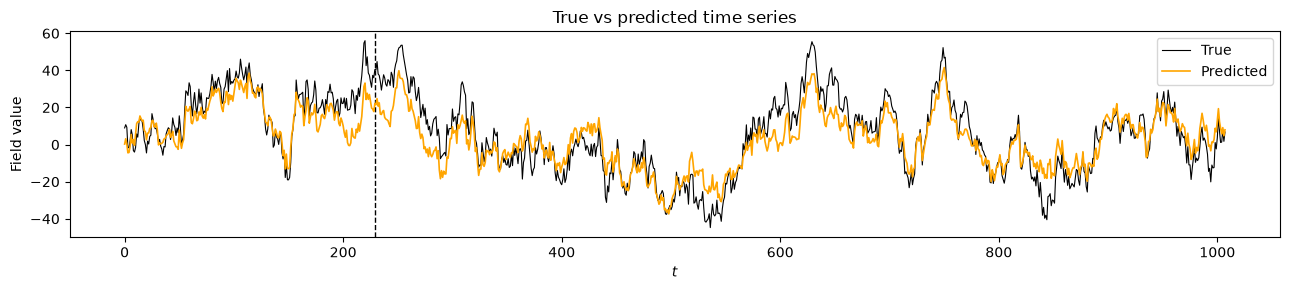

In [10]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.axvline(timestamp, color="black", linestyle="--", linewidth=1)
ax.plot(bundle.y_test[loc, :], label="True", color="black", linewidth=0.8)
ax.plot(y_hat_test[loc, :], label="Predicted", color="orange", linewidth=1.2)
ax.set_xlabel("$t$")
ax.set_ylabel("Field value")
ax.legend()
ax.set_title("True vs predicted time series")
plt.tight_layout()
plt.show()

## 6. Control statistics (smoothing effect)

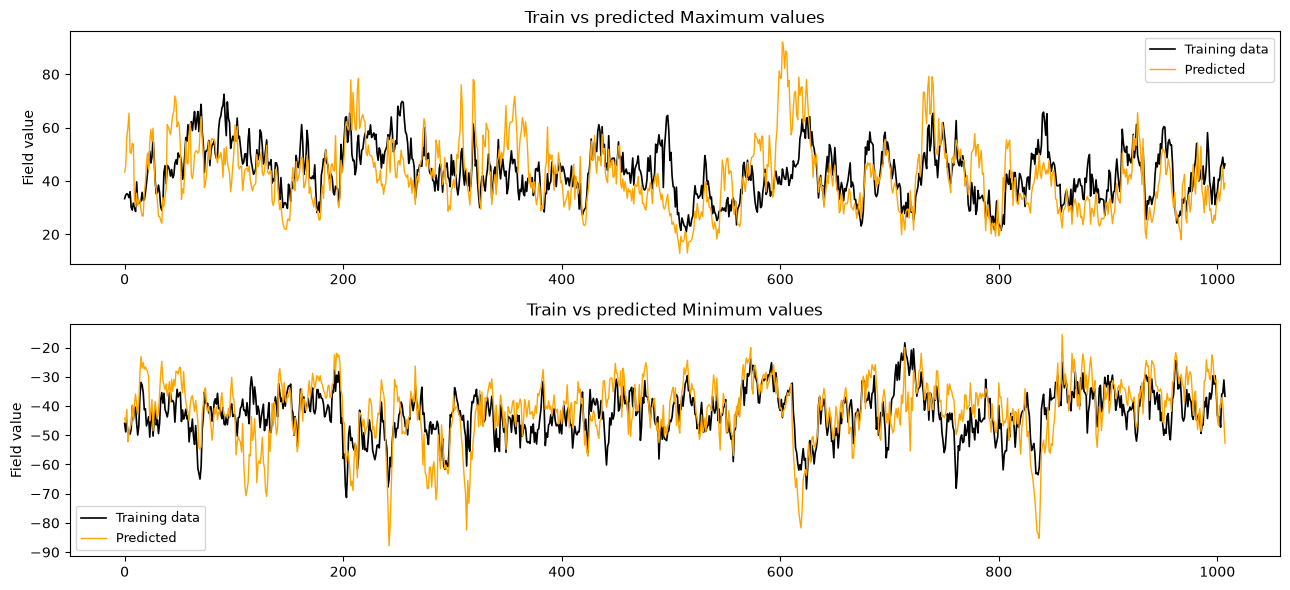

In [11]:
stats = control_stats(bundle.y_train, y_hat_mesh)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
for ax, col, title in zip(
    axes,
    ["y_max", "y_min"],
    ["Maximum values", "Minimum values"],
):
    ax.plot(stats[col].values, label="Training data", color="black", linewidth=1.2)
    ax.plot(stats[col.replace("y_", "mesh_")].values, label="Predicted", color="orange", linewidth=1)
    ax.set_title(f"Train vs predicted {title}")
    ax.set_ylabel("Field value")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()